# Terminal Benchmark Public API Demo

This notebook demonstrates the release-facing terminal benchmark API using local frozen artifacts. It stays on the public path only: load a frozen bundle, inspect the prediction contract, create baseline predictions, evaluate them, and run a few visual checks.

The terminal task asks: given one market's metadata and probability history available up to a cutoff, predict the final binary outcome. Each example is identified by `(market_id, horizon_hours)`, where `cutoff_timestamp_utc = end_date - horizon_hours`.


## Setup

The notebook resolves the repository root with `setup_root()` and expects frozen releases under `benchmark_releases/`.


In [1]:
import pandas as pd
from IPython.display import display

from polymarket_research.benchmarks import evaluate_terminal, load_terminal
from polymarket_research.benchmarks.baselines import (
    fit_terminal_last_probability_baseline,
    fit_terminal_train_rate_baseline,
)
from polymarket_research.benchmarks.audit.reporting import benchmark_manifest_summary
from polymarket_research.benchmarks.visualization.plotting import (
    plot_binary_calibration,
    plot_binary_label_rate_by_split,
    plot_label_distribution,
    plot_market_history,
    plot_metric_by_horizon,
    plot_precision_recall,
    plot_terminal_history_prefix_examples,
    plot_terminal_visible_history_diagnostics,
    select_terminal_history_prefix_examples,
)
from polymarket_research.utils.filesystem import setup_root

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.6f}".format)

REPO_ROOT = setup_root()
ARTIFACT_ROOT = REPO_ROOT / "benchmark_releases"
VERSION = "v1"
SOURCES = ("polymarket", "kalshi")


## Load Frozen Releases

The loader reads only frozen release files: `manifest.json`, `examples.parquet`, `targets.parquet`, and `market_timeseries.parquet`. No raw database loaders or benchmark builders are used here.


In [2]:
terminal_benchmarks = {
    source: load_terminal(ARTIFACT_ROOT / source / "terminal" / VERSION)
    for source in SOURCES
}

benchmark_manifest_summary(terminal_benchmarks)


,source,release_name,task,rows,markets,market_timeseries_rows,train_rows,test_rows,split_unit,split_unit_overlap,horizons_hours,positive_rate
0,polymarket,polymarket-terminal-24h-72h-168h,terminal_outcome_prediction,28359,11381,156568928,22660,5699,market_id,0,"[24, 72, 168]",0.217744
1,kalshi,kalshi-terminal-24h-72h-168h,terminal_outcome_prediction,6115,3480,94203240,4891,1224,market_id,0,"[24, 72, 168]",0.226983


## Inspect The Task Contract

`input_frame()` contains leakage-safe metadata and cutoff fields for each example. `targets()` is the scoring table with labels. A submitted prediction frame must contain exactly one prediction for every requested target row.


In [3]:
benchmark = terminal_benchmarks["polymarket"]

example_columns = [
    "market_id",
    "question",
    "end_date",
    "horizon_hours",
    "cutoff_timestamp_utc",
    "split",
]

display(benchmark.input_frame().loc[:, example_columns].sample(5))
display(benchmark.targets().sample(5))


,market_id,question,end_date,horizon_hours,cutoff_timestamp_utc,label,split
14933,541621,Will Johannes Kaiser win the Chilean president...,2025-11-16 12:00:00+00:00,24,2025-11-15 12:00:00+00:00,0,train
7537,553286,Will George Russell win the 2025 F1 Austrian G...,2025-06-29 00:00:00+00:00,72,2025-06-26 00:00:00+00:00,0,train
16557,992762,MicroStrategy announces >1000 BTC purchase Dec...,2025-12-30 05:00:00+00:00,168,2025-12-23 05:00:00+00:00,1,train
9200,562704,Dan Bongino out as Deputy Director of the FBI ...,2025-07-31 00:00:00+00:00,72,2025-07-28 00:00:00+00:00,0,train
11735,593301,NATO downs another Russian drone by September 30?,2025-09-30 00:00:00+00:00,24,2025-09-29 00:00:00+00:00,0,train


,market_id,horizon_hours,label,split
27710,691970,72,1,test
23959,811840,24,0,test
11510,599278,24,1,train
19844,1007366,24,0,train
4192,540179,72,0,train


## Prediction Frame Contract

For terminal evaluation, predictions must provide these columns:

- `market_id`
- `horizon_hours`
- `pred_prob`: predicted probability that the final resolved outcome is YES

The evaluator joins predictions to targets on `(market_id, horizon_hours)` and raises if any target row is missing.


In [4]:
prediction_template = benchmark.targets(split="test").loc[:, ["market_id", "horizon_hours"]].copy()
prediction_template["pred_prob"] = 0.5

print(f"Template rows: {len(prediction_template):,}")
display(prediction_template.head())


Template rows: 5,699


,market_id,horizon_hours,pred_prob
22660,1006467,168,0.500000
22661,1006468,168,0.500000
22662,1006469,168,0.500000
22663,1006470,168,0.500000
22664,1006471,168,0.500000


## What The Training Examples Contain

Before fitting baselines, inspect the training examples as model inputs. For each row, the model can use market metadata plus the probability history prefix ending at `cutoff_timestamp_utc`. The frozen bundle may contain later observations for plotting and audit, so filtering to the cutoff is part of the contract.


In [5]:
source = "polymarket"
benchmark = terminal_benchmarks[source]

train_inputs = benchmark.input_frame(split="train").copy()
train_targets = benchmark.targets(split="train").copy()
train_view = train_inputs.merge(
    train_targets,
    on=["market_id", "horizon_hours", "split"],
    how="left",
    validate="one_to_one",
)
train_view["visible_history_days"] = train_view["cutoff_age_hours"] / 24.0

train_preview_columns = [
    "market_id",
    "question",
    "horizon_hours",
    "created_at",
    "cutoff_timestamp_utc",
    "end_date",
    "visible_history_days",
    "current_yes_probability",
    "current_probability_timestamp_utc",
    "current_probability_staleness_hours",
    "label",
]
display(train_view.loc[:, train_preview_columns].head(10))

train_summary = (
    train_view.groupby("horizon_hours", sort=True)
    .agg(
        rows=("market_id", "size"),
        markets=("market_id", "nunique"),
        positive_rate=("label", "mean"),
        median_visible_history_days=("visible_history_days", "median"),
        p10_visible_history_days=("visible_history_days", lambda values: values.quantile(0.10)),
        p90_visible_history_days=("visible_history_days", lambda values: values.quantile(0.90)),
        median_cutoff_probability=("current_yes_probability", "median"),
    )
    .reset_index()
)
display(train_summary)


,market_id,question,horizon_hours,created_at,cutoff_timestamp_utc,end_date,visible_history_days,current_yes_probability,current_probability_timestamp_utc,current_probability_staleness_hours,label
0,517010,Will Trump attend Jimmy Carter's state funeral?,168,2025-01-01 11:55:07.248094+00:00,2025-01-02 12:00:00+00:00,2025-01-09 12:00:00+00:00,1.003388,0.980000,2025-01-02 12:00:00+00:00,0.000000,1
1,517049,Fact Check: Cybertruck explosion caused by lit...,24,2025-01-01 20:59:09.882827+00:00,2025-01-02 12:00:00+00:00,2025-01-03 12:00:00+00:00,0.625580,0.005000,2025-01-02 12:00:00+00:00,0.000000,0
2,517050,Fact Check: Cybertruck explosion intentional?,24,2025-01-01 21:14:29.220542+00:00,2025-01-02 12:00:00+00:00,2025-01-03 12:00:00+00:00,0.614940,0.760000,2025-01-02 12:00:00+00:00,0.000000,1
3,517052,Cybertruck explosion perp arrested by Sunday?,72,2025-01-01 21:30:56.148587+00:00,2025-01-02 12:00:00+00:00,2025-01-05 12:00:00+00:00,0.603517,0.110000,2025-01-02 12:00:00+00:00,0.000000,0
4,517052,Cybertruck explosion perp arrested by Sunday?,24,2025-01-01 21:30:56.148587+00:00,2025-01-04 12:00:00+00:00,2025-01-05 12:00:00+00:00,2.603517,0.006000,2025-01-04 12:00:00+00:00,0.000000,0
5,517170,Martial law in South Korea before Monday?,24,2025-01-02 23:18:47.351059+00:00,2025-01-04 12:00:00+00:00,2025-01-05 12:00:00+00:00,1.528619,0.002000,2025-01-04 12:00:00+00:00,0.000000,0
6,517242,Will 'Anora' win the Golden Globe for Best Mus...,24,2025-01-03 20:22:39.211851+00:00,2025-01-04 12:00:00+00:00,2025-01-05 12:00:00+00:00,0.650935,0.560000,2025-01-04 12:00:00+00:00,0.000000,0
7,517247,Will 'Wicked' win the Golden Globe for Best Mu...,24,2025-01-03 20:32:16.023500+00:00,2025-01-04 12:00:00+00:00,2025-01-05 12:00:00+00:00,0.644259,0.180000,2025-01-04 12:00:00+00:00,0.000000,0
8,517250,Will Adrien Brody win the Golden Globe for Bes...,24,2025-01-03 20:46:46.317766+00:00,2025-01-04 12:00:00+00:00,2025-01-05 12:00:00+00:00,0.634186,0.660000,2025-01-04 12:00:00+00:00,0.000000,1
9,517257,Will Selena Gomez win the Golden Globe for Bes...,24,2025-01-03 21:06:06.040242+00:00,2025-01-04 12:00:00+00:00,2025-01-05 12:00:00+00:00,0.620763,0.031000,2025-01-04 12:00:00+00:00,0.000000,0


,horizon_hours,rows,markets,positive_rate,median_visible_history_days,p10_visible_history_days,p90_visible_history_days,median_cutoff_probability
0,24,8218,8218,0.224751,22.099872,2.526718,131.595235,0.029000
1,72,7828,7828,0.216403,24.414679,2.800915,135.595054,0.040000
2,168,6614,6614,0.191715,27.653267,4.090601,155.163808,0.030000


(<Axes: title={'center': 'Polymarket train visible history window'}, xlabel='days from market creation to cutoff', ylabel='examples'>,
 <Axes: title={'center': 'Polymarket train current cutoff probability'}, xlabel='yes_probability at cutoff', ylabel='examples'>)

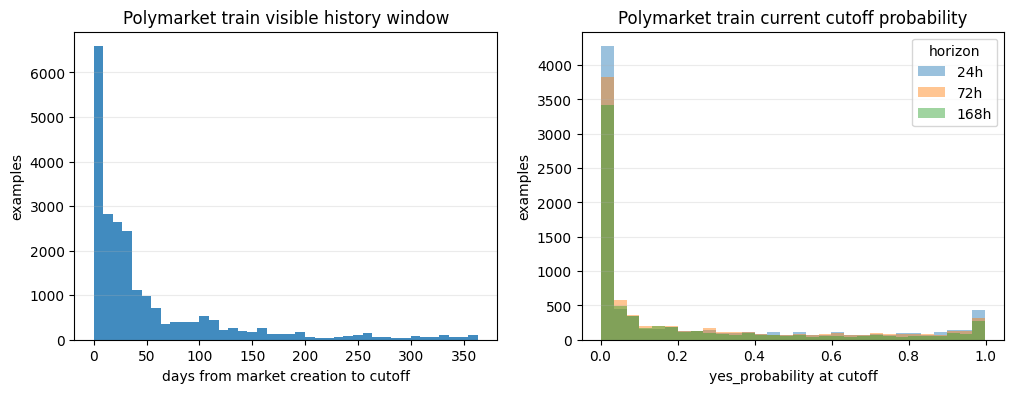

In [6]:
plot_terminal_visible_history_diagnostics(
    benchmark,
    split="train",
    frame=train_view,
    title_prefix="Polymarket",
)


,market_id,question,horizon_hours,visible_history_days,current_yes_probability,label
0,528903,Will George Russell win the 2025 Chinese Grand...,24,1.982954,0.029000,0
1,520793,Will egg prices be between $4.25-4.50 for Janu...,72,10.746704,0.040000,0
2,518208,Will USD0++ stabilize again before February?,168,13.600755,0.030000,0


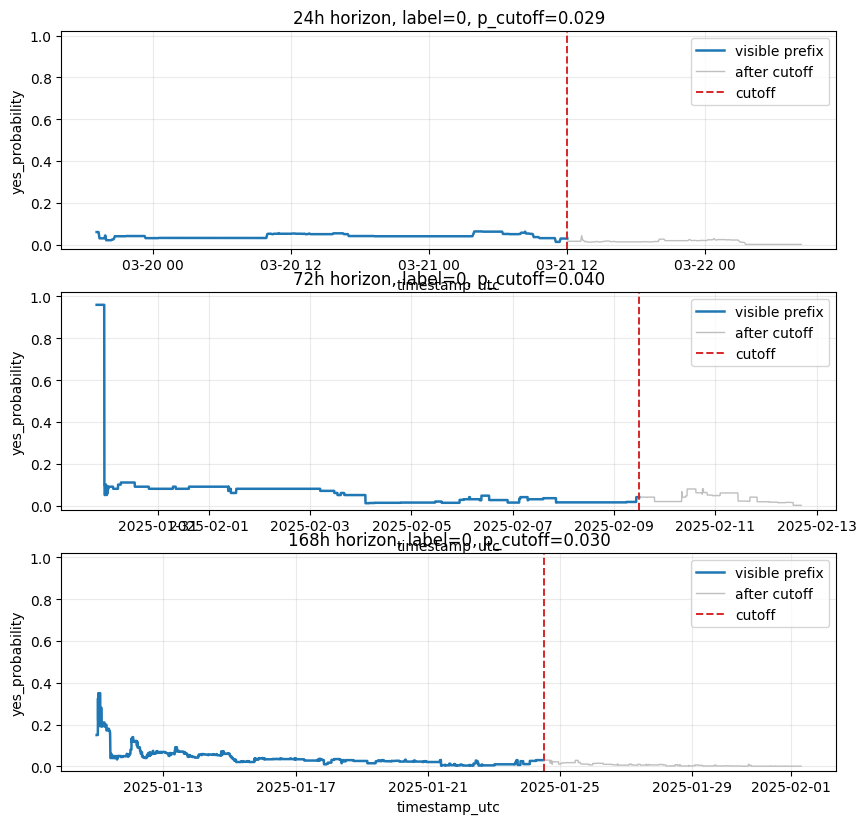

In [7]:
sample_train_examples = select_terminal_history_prefix_examples(benchmark, split="train")
sample_train_examples = sample_train_examples.merge(
    benchmark.targets(split="train"),
    on=["market_id", "horizon_hours", "split"],
    how="left",
    validate="one_to_one",
)
plot_terminal_history_prefix_examples(benchmark, sample_train_examples)

display(sample_train_examples.loc[:, [
    "market_id",
    "question",
    "horizon_hours",
    "visible_history_days",
    "current_yes_probability",
    "label",
]])


## Baseline Evaluation

The market-implied baseline uses the latest market probability at each cutoff. Its market-relative metrics are therefore exactly zero by construction. The constant baselines make the comparison meaningful: positive `market_skill_log_loss` means better than the market reference, negative means worse.


In [8]:
def uniform_predictions(benchmark, *, split: str = "test", pred_prob: float = 0.5) -> pd.DataFrame:
    predictions = benchmark.targets(split=split).loc[:, ["market_id", "horizon_hours"]].copy()
    predictions["pred_prob"] = float(pred_prob)
    return predictions


def terminal_baseline_predictions(benchmark, *, split: str = "test") -> dict[str, pd.DataFrame]:
    train_rate_baseline = fit_terminal_train_rate_baseline(benchmark, split="train")
    market_baseline = fit_terminal_last_probability_baseline(benchmark, split="train")
    return {
        "uniform_0_5": uniform_predictions(benchmark, split=split, pred_prob=0.5),
        "train_rate": train_rate_baseline.predict(benchmark, split=split),
        "market_last_probability": market_baseline.predict(benchmark, split=split),
    }


baseline_predictions = {}
baseline_reports = {}
overall_rows = []
horizon_rows = []

for source, benchmark in terminal_benchmarks.items():
    for baseline_name, predictions in terminal_baseline_predictions(benchmark).items():
        report = evaluate_terminal(benchmark, predictions, split="test")
        baseline_predictions[(source, baseline_name)] = predictions
        baseline_reports[(source, baseline_name)] = report

        overall_row = report["overall"].iloc[0].to_dict()
        overall_row.update({"source": source, "baseline": baseline_name})
        overall_rows.append(overall_row)

        by_horizon = report["by_horizon"].copy()
        by_horizon["source"] = source
        by_horizon["baseline"] = baseline_name
        horizon_rows.append(by_horizon)

overall_summary = pd.DataFrame(overall_rows).loc[:, [
    "source",
    "baseline",
    "split",
    "rows",
    "log_loss",
    "brier_score",
    "roc_auc",
    "delta_log_loss_vs_market",
    "market_skill_log_loss",
]]

horizon_summary = pd.concat(horizon_rows, ignore_index=True).loc[:, [
    "source",
    "baseline",
    "split",
    "horizon_hours",
    "rows",
    "log_loss",
    "brier_score",
    "roc_auc",
    "delta_log_loss_vs_market",
    "market_skill_log_loss",
]]

display(overall_summary.sort_values(["source", "log_loss"], kind="stable"))


,source,baseline,split,rows,log_loss,brier_score,roc_auc,delta_log_loss_vs_market,market_skill_log_loss
5,kalshi,market_last_probability,test,1235,0.134879,0.037578,0.988156,0.000000,0.000000
4,kalshi,train_rate,test,1235,0.579027,0.194603,0.500000,-0.444148,-3.292925
3,kalshi,uniform_0_5,test,1235,0.693147,0.250000,0.500000,-0.558268,-4.139017
2,polymarket,market_last_probability,test,5699,0.236859,0.073749,0.950046,0.000000,0.000000
1,polymarket,train_rate,test,5699,0.552914,0.182994,0.500000,-0.316055,-1.334360
0,polymarket,uniform_0_5,test,5699,0.693147,0.250000,0.500000,-0.456288,-1.926416


In [9]:
display(horizon_summary.sort_values(["source", "baseline", "horizon_hours"], kind="stable"))


,source,baseline,split,horizon_hours,rows,log_loss,brier_score,roc_auc,delta_log_loss_vs_market,market_skill_log_loss
15,kalshi,market_last_probability,test,24,199,0.105318,0.029792,0.993561,0.000000,0.000000
16,kalshi,market_last_probability,test,72,228,0.169835,0.048891,0.976238,0.000000,0.000000
17,kalshi,market_last_probability,test,168,808,0.132296,0.036303,0.989879,0.000000,0.000000
12,kalshi,train_rate,test,24,199,0.547624,0.180742,0.500000,-0.442306,-4.199713
13,kalshi,train_rate,test,72,228,0.531637,0.173686,0.500000,-0.361802,-2.130309
14,kalshi,train_rate,test,168,808,0.600133,0.203919,0.500000,-0.467837,-3.536290
9,kalshi,uniform_0_5,test,24,199,0.693147,0.250000,0.500000,-0.587829,-5.581468
10,kalshi,uniform_0_5,test,72,228,0.693147,0.250000,0.500000,-0.523312,-3.081292
11,kalshi,uniform_0_5,test,168,808,0.693147,0.250000,0.500000,-0.560851,-4.239362
6,polymarket,market_last_probability,test,24,1938,0.219170,0.067540,0.959161,0.000000,0.000000


## Visual Checks

These plots use only frozen artifacts, prediction frames, and evaluator reports. The example below focuses on Polymarket; the same calls work for Kalshi by changing `source`.


<Axes: title={'center': 'Polymarket terminal test labels'}, xlabel='label', ylabel='rows'>

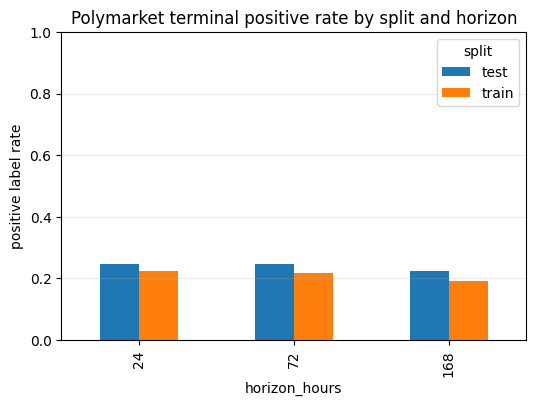

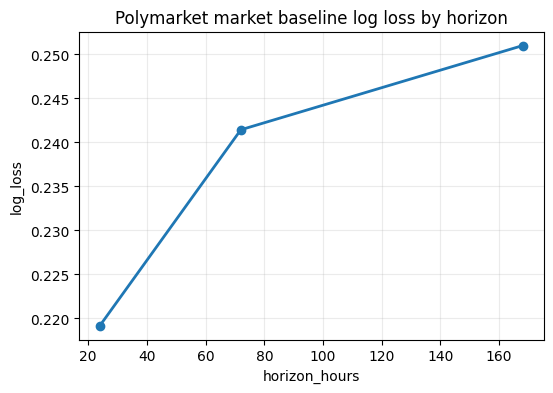

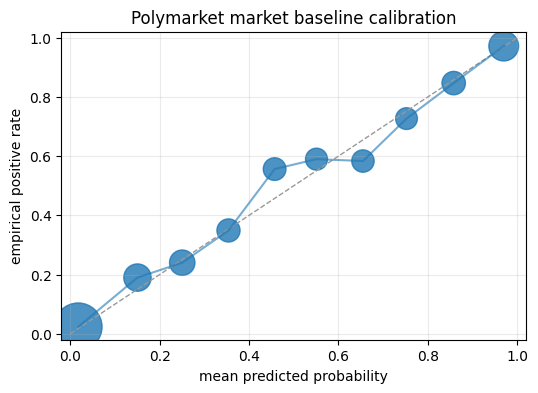

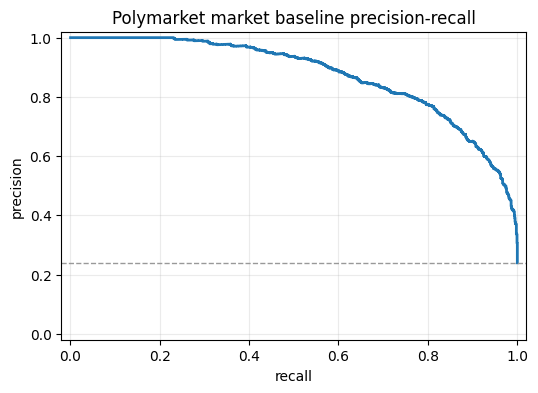

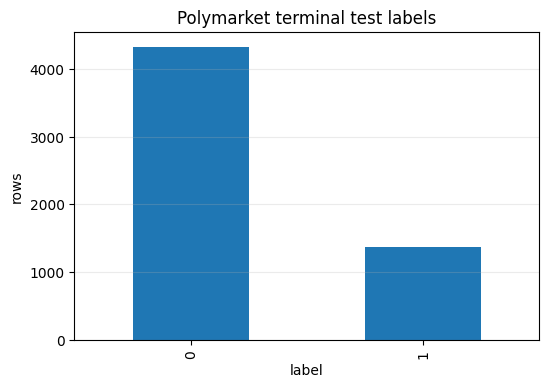

In [10]:
source = "polymarket"
benchmark = terminal_benchmarks[source]
predictions = baseline_predictions[(source, "market_last_probability")]
report = baseline_reports[(source, "market_last_probability")]

plot_binary_label_rate_by_split(
    benchmark,
    group_col="horizon_hours",
    title="Polymarket terminal positive rate by split and horizon",
)
plot_metric_by_horizon(report, metric="log_loss", title="Polymarket market baseline log loss by horizon")
plot_binary_calibration(benchmark, predictions, split="test", title="Polymarket market baseline calibration")
plot_precision_recall(benchmark, predictions, split="test", title="Polymarket market baseline precision-recall")
plot_label_distribution(benchmark, split="test", title="Polymarket terminal test labels")


## Optional Inspection

A model should only use observations at or before `cutoff_timestamp_utc`. This inspection shows the visible prefix for one held-out example and overlays the cutoff on the full market history plot for context.


market_id                                                        1006467
question                Will Jannik Sinner win the 2026 Australian Open?
end_date                                       2026-02-01 00:00:00+00:00
horizon_hours                                                        168
cutoff_timestamp_utc                           2026-01-25 00:00:00+00:00
label                                                                  0
split                                                               test
Name: 22660, dtype: object

,market_id,timestamp_utc,yes_probability
9159,1006467,2026-01-24 23:40:00+00:00,0.510000
9160,1006467,2026-01-24 23:45:00+00:00,0.510000
9161,1006467,2026-01-24 23:50:00+00:00,0.510000
9162,1006467,2026-01-24 23:55:00+00:00,0.510000
9163,1006467,2026-01-25 00:00:00+00:00,0.510000


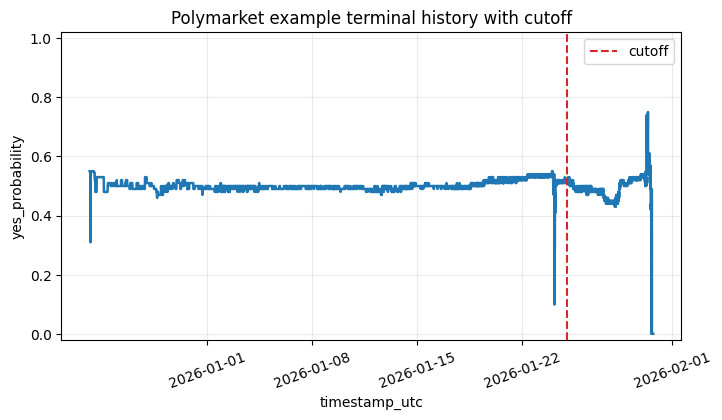

In [11]:
source = "polymarket"
benchmark = terminal_benchmarks[source]
example = benchmark.input_frame(split="test").iloc[0]
market_id = str(example["market_id"])
cutoff = pd.Timestamp(example["cutoff_timestamp_utc"])
target_row = benchmark.targets(split="test").loc[
    lambda df: (df["market_id"].astype(str) == market_id)
    & (df["horizon_hours"].eq(example["horizon_hours"]))
].iloc[0]

history = benchmark.market_history(market_id).copy()
history["timestamp_utc"] = pd.to_datetime(history["timestamp_utc"], utc=True, errors="coerce")
visible_history = history.loc[history["timestamp_utc"].le(cutoff)].copy()

plot_market_history(
    benchmark,
    market_id=market_id,
    cutoff=cutoff,
    title="Polymarket example terminal history with cutoff",
)

example_display = pd.concat([
    example,
    target_row.drop(labels=["market_id", "horizon_hours", "split"], errors="ignore"),
])
display(example_display.loc[[
    "market_id",
    "question",
    "end_date",
    "horizon_hours",
    "cutoff_timestamp_utc",
    "label",
    "split",
]])
display(visible_history.tail())
